# Training 2 Separate DeBERTa Models (Binary Classifier and Multi-Class Classifier)

Firstly, understanding the problem. We are wanting to take a pre-trained model (DeBERTa in this case) and fine tune it so it aligns with our particular goals and labelling. 

**Goal: A model that can classify a student survey response into 2 labels:**
- Appropriateness: appropriate/inappropriate
- Category: teaching & delivery/course materials & structure/assignment & quiz

This allows the PandA team to be able to use the model to classify responses and then easily filter out inappropriate responses. It then also allows them to analyse responses by category. For example, if they want to specifically focus on responses regarding course structure & materials, they can do that. 

**Approach: Fine-tune a DeBERTa model so it can take a student survey response and classify it into 2 labels.**

1. Appropriateness → Binary Classification:
    - appropriate
    - inappropriate

**Approach: Fine-tune a DeBERTa model so it can take a student survey response and classify it into 4 labels.**

2. Category → Multi-class Classification:
    - course materials & structure
    - teaching & delivery
    - assignment & quiz
    - mixed

**Evaluation Metrics:**
- Appropriateness (binary classification)
    - Accuracy
    - Precision, Recall, F1 Score
- Category (multi-class classification)
    - Accuracy
    - Macro-F1 
    - Confusion Matrix

Accuracy:
- Correct Predictions / Total Predictions
- Accuracy is a good metric to use when classes are balanced. 

Precision:
- True Positives / (True Positives + False Positives)
- When the model says yes, how often is it correct?
- How trustworthy the predictions are

Recall:
- True Positives / (True Positives + False Negatives)
- Out of all the real yes cases, how many did the model find?
- How complete the predictions are

F1 Score:
- 2 x (Precision x Recall) / (Precision + Recall)
- Balances between precision and recall
- Especially useful if the data is imbalanced (in our case yes)

Macro F1:
- Compute F1 for each class separately, then take the average. 
- Ensures that smaller classes are not ignored
- More informative than accuracy (accuracy could be good while the model performs poorly on one category)

Confusion Matrix:
- Helps you see where the model confuses categories. 


### Setting Seeds

In [1]:
import pandas as pd

import torch
import numpy as np
import random
from transformers import set_seed
import os

import warnings
warnings.filterwarnings('ignore') 

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

# Set all seeds
set_all_seeds(42)

c:\Users\usman\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data

In [2]:
import pandas as pd
clean_df = pd.read_excel("synthetic_data_mixed_labels.xlsx")


# Checking the data proportion
print("Appropriate/Inappropriate Proportion:")
print(clean_df['inappropriate_appropriate'].value_counts(normalize=True).round(2))
 
 
print("\nCategory Proportion:")
print(clean_df['category_mixed'].value_counts(normalize=True).round(2))

Appropriate/Inappropriate Proportion:
inappropriate_appropriate
appropriate      0.75
inappropriate    0.25
Name: proportion, dtype: float64

Category Proportion:
category_mixed
mixed                           0.34
teaching & delivery             0.25
course materials & structure    0.24
assignment & quiz               0.18
Name: proportion, dtype: float64


### Filter Data

In [3]:
# Filters out any responses that are less than 10 characters
clean_df = clean_df[clean_df['student_response'].str.len()>10].copy()
clean_df

,course_name,question,student_response,inappropriate_appropriate,category,category_mixed,all_labels
0,Introduction to Computer Science,Which aspects of this course need improvement?,the lecture recordings are often unclear and t...,appropriate,teaching & delivery,teaching & delivery,['teaching & delivery']
1,Mathematical Methods,Which aspects of this course need improvement?,this course sucks and prof smith is the worst ...,inappropriate,teaching & delivery,mixed,"['teaching & delivery', 'course materials & st..."
2,Physics for Engineers,Which aspects of this course need improvement?,the assignment instructions are very ambiguous...,appropriate,assignment & quiz,mixed,"['assignment & quiz', 'course materials & stru..."
3,General Chemistry,Which aspects of this course need improvement?,the lab manual is outdated and some experiment...,appropriate,course materials & structure,course materials & structure,['course materials & structure']
4,Introduction to Biology,Which aspects of this course need improvement?,good course overall.,appropriate,teaching & delivery,course materials & structure,['course materials & structure']
...,...,...,...,...,...,...,...
670,Educational Psychology,Which aspects of this course need improvement?,the professor talks down to students like we'r...,inappropriate,teaching & delivery,teaching & delivery,['teaching & delivery']
671,Financial Accounting,What are the best aspects of this course?,the practice exams accurately reflect the diff...,appropriate,assignment & quiz,assignment & quiz,['assignment & quiz']
672,Astronomy,Which aspects of this course need improvement?,the lab manual has several errors in the calcu...,appropriate,course materials & structure,course materials & structure,['course materials & structure']
673,Abnormal Psychology,What are the best aspects of this course?,the professor presents sensitive topics with a...,appropriate,teaching & delivery,teaching & delivery,['teaching & delivery']


### Concatenating Labels

In [4]:
from sklearn.model_selection import train_test_split
 
# Concatenate the 'inappropriate_appropriate' and 'category' columns into a single column
clean_df['concat_labels'] = clean_df['inappropriate_appropriate'] + '_' + clean_df['category_mixed']

### Encoding

In [5]:
# Encode the labels
app_map = {"inappropriate": 0, "appropriate": 1}
category_map = {"teaching & delivery": 0, "assignment & quiz": 1, "course materials & structure": 2, "mixed": 3}
 
clean_df['inappropriate_appropriate'] = clean_df['inappropriate_appropriate'].map(app_map)
clean_df['category_mixed'] = clean_df['category_mixed'].map(category_map)

In [6]:
clean_df.head(5)

,course_name,question,student_response,inappropriate_appropriate,category,category_mixed,all_labels,concat_labels
0,Introduction to Computer Science,Which aspects of this course need improvement?,the lecture recordings are often unclear and t...,1,teaching & delivery,0,['teaching & delivery'],appropriate_teaching & delivery
1,Mathematical Methods,Which aspects of this course need improvement?,this course sucks and prof smith is the worst ...,0,teaching & delivery,3,"['teaching & delivery', 'course materials & st...",inappropriate_mixed
2,Physics for Engineers,Which aspects of this course need improvement?,the assignment instructions are very ambiguous...,1,assignment & quiz,3,"['assignment & quiz', 'course materials & stru...",appropriate_mixed
3,General Chemistry,Which aspects of this course need improvement?,the lab manual is outdated and some experiment...,1,course materials & structure,2,['course materials & structure'],appropriate_course materials & structure
4,Introduction to Biology,Which aspects of this course need improvement?,good course overall.,1,teaching & delivery,2,['course materials & structure'],appropriate_course materials & structure


### Splitting the Data

In [7]:
# Split the data
train_df, test_df = train_test_split(clean_df,
                                     test_size=0.2,
                                     random_state=42,
                                     stratify=clean_df['concat_labels'])
 
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (540, 8)
Test shape: (135, 8)


### Load Tokeniser and Model

In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Model: DeBERTa-v3-base (light but strong) microsoft/deberta-v3-base
MODEL_NAME = "microsoft/deberta-v3-base"

# Loading Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

# Binary model for appropriateness classification and multi-class model for category classification
binary_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
multi_class_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=4)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
# Ensure model runs on GPU
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

binary_model.to(device)
multi_class_model.to(device)

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

### Layer Freezing

In [10]:
def freeze_lower_layers(model, num_layers_to_freeze=8):
    # Freeze embedding and first N encoder layers
    for param in model.deberta.embeddings.parameters():
        param.requires_grad = False
    
    for i in range(num_layers_to_freeze):
        for param in model.deberta.encoder.layer[i].parameters():
            param.requires_grad = False

    print(f"Frozen first {num_layers_to_freeze} layers and embeddings")
    
    # Print number of trainable parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")

freeze_lower_layers(multi_class_model, num_layers_to_freeze=8)
freeze_lower_layers(binary_model, num_layers_to_freeze=8)

Frozen first 8 layers and embeddings
Total parameters: 184,425,220
Trainable parameters: 29,339,908
Frozen parameters: 155,085,312
Frozen first 8 layers and embeddings
Total parameters: 184,423,682
Trainable parameters: 29,338,370
Frozen parameters: 155,085,312


### Prepare Hugging Face Datasets and Tokenise

In [11]:
from datasets import Dataset

# Dropping unnecessary columns
train_df_binary = train_df.drop(['course_name', 'question', 'category_mixed','category'], axis=1)
test_df_binary = test_df.drop(['course_name', 'question', 'category_mixed','category'], axis=1)

train_df_multi_class = train_df.drop(['course_name', 'question', 'inappropriate_appropriate','category'], axis=1)
test_df_multi_class = test_df.drop(['course_name', 'question', 'inappropriate_appropriate','category'], axis=1)

In [12]:
train_dataset_binary = Dataset.from_pandas(train_df_binary) 
test_dataset_binary = Dataset.from_pandas(test_df_binary)

train_dataset_multi_class = Dataset.from_pandas(train_df_multi_class) 
test_dataset_multi_class = Dataset.from_pandas(test_df_multi_class)

In [13]:
# Creating a function for tokenising and then mapping that across the dataset
def tokenize(batch):
    texts = [str(x) for x in batch["student_response"]]
    return tokenizer(texts, 
                     padding="max_length", 
                     truncation=True, 
                     max_length=256)

train_dataset_binary = train_dataset_binary.map(tokenize, batched=True)
test_dataset_binary = test_dataset_binary.map(tokenize, batched=True)

train_dataset_multi_class = train_dataset_multi_class.map(tokenize, batched=True)
test_dataset_multi_class = test_dataset_multi_class.map(tokenize, batched=True)

Map: 100%|██████████| 135/135 [00:00<00:00, 4467.94 examples/s]


### Define Labels Column

In [14]:
train_dataset_binary = train_dataset_binary.rename_column("inappropriate_appropriate", "labels")
test_dataset_binary = test_dataset_binary.rename_column("inappropriate_appropriate", "labels")

train_dataset_multi_class = train_dataset_multi_class.rename_column("category_mixed", "labels")
test_dataset_multi_class = test_dataset_multi_class.rename_column("category_mixed", "labels")

In [15]:
print(train_dataset_binary)
print(test_dataset_binary)

print(train_dataset_multi_class)
print(test_dataset_multi_class)

Dataset({
    features: ['student_response', 'labels', 'all_labels', 'concat_labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 540
})
Dataset({
    features: ['student_response', 'labels', 'all_labels', 'concat_labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 135
})
Dataset({
    features: ['student_response', 'labels', 'all_labels', 'concat_labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 540
})
Dataset({
    features: ['student_response', 'labels', 'all_labels', 'concat_labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 135
})


In [16]:
train_dataset_binary = train_dataset_binary.remove_columns('__index_level_0__')
test_dataset_binary = test_dataset_binary.remove_columns('__index_level_0__')

train_dataset_multi_class = train_dataset_multi_class.remove_columns('__index_level_0__')
test_dataset_multi_class = test_dataset_multi_class.remove_columns('__index_level_0__')

In [17]:
print(train_dataset_binary)
print(test_dataset_binary)

print(train_dataset_multi_class)
print(test_dataset_multi_class)

Dataset({
    features: ['student_response', 'labels', 'all_labels', 'concat_labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 540
})
Dataset({
    features: ['student_response', 'labels', 'all_labels', 'concat_labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 135
})
Dataset({
    features: ['student_response', 'labels', 'all_labels', 'concat_labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 540
})
Dataset({
    features: ['student_response', 'labels', 'all_labels', 'concat_labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 135
})


In [18]:
train_dataset_binary.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset_binary.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_dataset_multi_class.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset_multi_class.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

### Define Metrics

In [19]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    prec, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")

    return {"accuracy" : acc, "precision": prec, "recall": recall, "f1": f1}

### Implementing Class Weighting

In [20]:
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# Creating a weighted trainer (unchanged)
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        loss_fct = CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

category_map = {
    "teaching & delivery": 0, 
    "assignment & quiz": 1, 
    "course materials & structure": 2,
    "mixed": 3  
}

# Calculate class weights for 4 classes
train_labels = [item['labels'].item() for item in train_dataset_multi_class]
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),  # This will automatically detect all 4 classes
    y=train_labels
)
class_weights = torch.FloatTensor(class_weights).to(device)

print("Class weights:", class_weights)
print("This means:")
print(f"  Teaching & delivery (0): {class_weights[0]:.3f}")
print(f"  Assignment & quiz (1): {class_weights[1]:.3f}")  
print(f"  Course materials & structure (2): {class_weights[2]:.3f}")
print(f"  Mixed (3): {class_weights[3]:.3f}")

# Print class distribution to verify
unique_labels, counts = np.unique(train_labels, return_counts=True)
print("\nClass distribution in training data:")
for label, count in zip(unique_labels, counts):
    class_names = {0: "Teaching & delivery", 1: "Assignment & quiz", 
                   2: "Course materials & structure", 3: "Mixed"}
    percentage = (count / len(train_labels)) * 100
    print(f"  {class_names[label]}: {count} samples ({percentage:.1f}%)")

# The higher the weight, the more the model will focus on that class
# Classes with fewer samples will typically get higher weights

Class weights: tensor([1.0075, 1.4211, 1.0547, 0.7377], device='cuda:0')
This means:
  Teaching & delivery (0): 1.007
  Assignment & quiz (1): 1.421
  Course materials & structure (2): 1.055
  Mixed (3): 0.738

Class distribution in training data:
  Teaching & delivery: 134 samples (24.8%)
  Assignment & quiz: 95 samples (17.6%)
  Course materials & structure: 128 samples (23.7%)
  Mixed: 183 samples (33.9%)


### Training Arguments and Trainer

In [21]:
training_args_binary = TrainingArguments(
    # Evaluation and saving strategies
    output_dir="./results_binary",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    
    # Early stopping configuration
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Learning parameters
    learning_rate=2e-5,
    per_device_eval_batch_size=8,
    per_device_train_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    warmup_steps=25,

    # GPU Optimisations
    fp16=True,
    dataloader_pin_memory=False,
    dataloader_num_workers=5,
    
    logging_dir="./binary_logs",
    seed=42,
)


training_args_multi_class = TrainingArguments(
    # Evaluation and saving strategies
    output_dir="./results_multi_class", # Change depending on which model you are running (binary/multi-class)
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    
    # Early stopping configuration
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Learning parameters
    learning_rate=3e-5,
    per_device_eval_batch_size=8,
    per_device_train_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    warmup_steps=15,

    # GPU Optimisations
    fp16=True,
    dataloader_pin_memory=False,
    dataloader_num_workers=5,
    
    logging_dir="./multi_class_logs",
    seed=42,
)

In [22]:
# Early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    # Stop if no improvement for 3 epochs
    early_stopping_patience=3,

    # Minimum change to qualify as improvement
    early_stopping_threshold=0.003
)

# Training for Binary Classifier
binary_trainer = Trainer(
    model=binary_model,
    args=training_args_binary,
    train_dataset=train_dataset_binary,
    eval_dataset=test_dataset_binary,
    tokenizer=tokenizer,
    compute_metrics = compute_metrics,
    callbacks = [early_stopping_callback],
)

# Training for Multi-Class Classifier
multi_class_trainer = WeightedTrainer(
    model=multi_class_model,
    args=training_args_multi_class,
    train_dataset=train_dataset_multi_class,
    eval_dataset=test_dataset_multi_class,
    tokenizer=tokenizer,
    compute_metrics = compute_metrics,
    callbacks = [early_stopping_callback],
    class_weights = class_weights
)

### Train Model

In [23]:
binary_trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.582600,0.413186,0.748148,0.559726,0.748148,0.640364
2,0.240900,0.128419,0.992593,0.992804,0.992593,0.992628
3,0.063000,0.003049,1.000000,1.000000,1.000000,1.000000
4,0.012100,0.000853,1.000000,1.000000,1.000000,1.000000
5,0.008700,0.000622,1.000000,1.000000,1.000000,1.000000
6,0.000900,0.001916,1.000000,1.000000,1.000000,1.000000


TrainOutput(global_step=204, training_loss=0.1513556345895517, metrics={'train_runtime': 363.1652, 'train_samples_per_second': 14.869, 'train_steps_per_second': 0.936, 'total_flos': 426247553802240.0, 'train_loss': 0.1513556345895517, 'epoch': 6.0})

In [24]:
multi_class_trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.377600,1.274040,0.570370,0.477231,0.570370,0.513553
2,1.132800,1.014715,0.637037,0.648135,0.637037,0.636166
3,0.923900,0.960881,0.585185,0.530751,0.585185,0.549295
4,0.796600,0.840398,0.696296,0.730303,0.696296,0.696827
5,0.637600,0.748976,0.740741,0.751524,0.740741,0.739618
6,0.501800,0.698456,0.777778,0.780984,0.777778,0.774880
7,0.416000,0.696813,0.755556,0.767452,0.755556,0.750939
8,0.341300,0.704611,0.777778,0.793270,0.777778,0.777930
9,0.288300,0.674028,0.785185,0.795429,0.785185,0.782940
10,0.250200,0.680914,0.785185,0.793144,0.785185,0.782699


TrainOutput(global_step=340, training_loss=0.6666228687061982, metrics={'train_runtime': 549.9141, 'train_samples_per_second': 9.82, 'train_steps_per_second': 0.618, 'total_flos': 710425346457600.0, 'train_loss': 0.6666228687061982, 'epoch': 10.0})

### Multi Class Training Results Analysis

Classification Report:
                              precision    recall  f1-score   support

         teaching & delivery       0.87      0.79      0.83        33
           assignment & quiz       0.67      0.92      0.77        24
course materials & structure       0.80      0.61      0.69        33
                       mixed       0.81      0.84      0.83        45

                    accuracy                           0.79       135
                   macro avg       0.79      0.79      0.78       135
                weighted avg       0.80      0.79      0.78       135



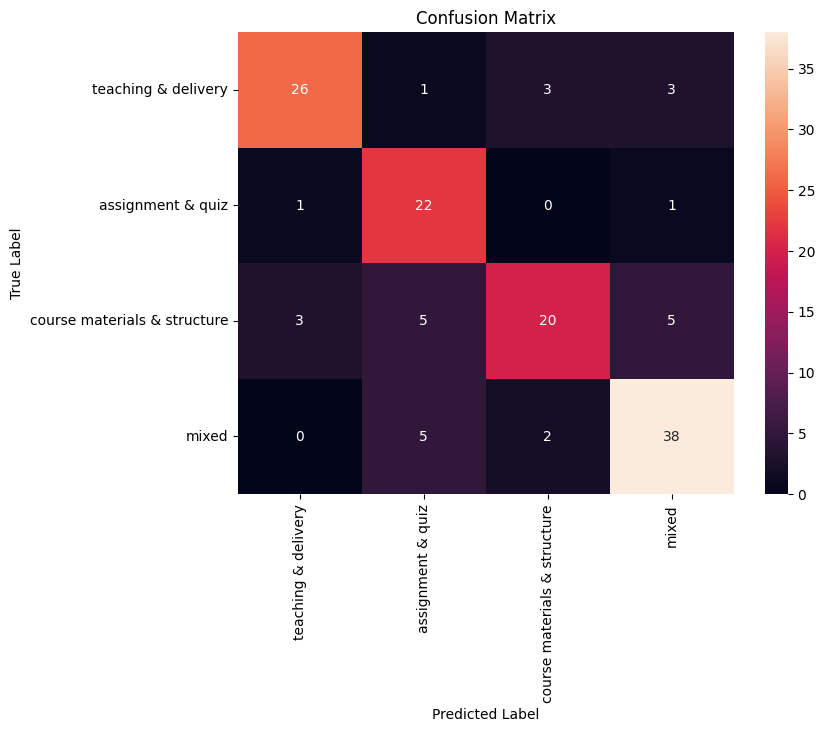

In [25]:
# Analysing Multi-Class Results
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def detailed_evaluation(trainer, test_dataset, category_map):
    predictions = trainer.predict(test_dataset)
    y_pred = predictions.predictions.argmax(-1)
    y_true = predictions.label_ids
    
    # Reverse the category mapping for readable labels
    reverse_map = {v: k for k, v in category_map.items()}
    labels = [reverse_map[i] for i in range(len(reverse_map))]
    
    # Classification report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return y_true, y_pred

category_map = {"teaching & delivery": 0, "assignment & quiz": 1, "course materials & structure": 2, "mixed": 3}
y_true, y_pred = detailed_evaluation(multi_class_trainer, test_dataset_multi_class, category_map)

### Evaluation

In [26]:
# Load your separate unseen data
unseen_df = pd.read_excel('synthetic_data_test.xlsx')

# Apply the same filtering (responses longer than 10 characters)
unseen_df = unseen_df[unseen_df['student_response'].str.len() > 10].copy()

# Encoding
unseen_df['inappropriate_appropriate'] = unseen_df['inappropriate_appropriate'].map(app_map)
unseen_df['category_mixed'] = unseen_df['category_mixed'].map(category_map)

# Dropping unnecessary columns
unseen_df_binary = unseen_df.drop(['course_name', 'question', 'category_mixed', 'category', 'all_labels'], axis=1)
unseen_df_multi = unseen_df.drop(['course_name', 'question', 'inappropriate_appropriate','category', 'all_labels'], axis=1)

# Converting to hugging face dataset
unseen_binary_dataset = Dataset.from_pandas(unseen_df_binary) 
unseen_multi_dataset = Dataset.from_pandas(unseen_df_multi)

# Tokenising
unseen_binary_dataset = unseen_binary_dataset.map(tokenize, batched=True)
unseen_multi_dataset = unseen_multi_dataset.map(tokenize, batched=True)

# Renaming columns
unseen_binary_dataset = unseen_binary_dataset.rename_column("inappropriate_appropriate", "labels")
unseen_multi_dataset = unseen_multi_dataset.rename_column("category_mixed", "labels")

# Setting to torch format
unseen_binary_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
unseen_multi_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 104/104 [00:00<00:00, 6688.76 examples/s]


In [27]:
binary_trainer.evaluate(unseen_binary_dataset)

{'eval_loss': 0.3229321837425232,
 'eval_accuracy': 0.9326923076923077,
 'eval_precision': 0.9345414201183432,
 'eval_recall': 0.9326923076923077,
 'eval_f1': 0.93085458169111,
 'eval_runtime': 24.3908,
 'eval_samples_per_second': 4.264,
 'eval_steps_per_second': 0.533,
 'epoch': 6.0}

In [28]:
multi_class_trainer.evaluate(unseen_multi_dataset)

{'eval_loss': 1.2185654640197754,
 'eval_accuracy': 0.6153846153846154,
 'eval_precision': 0.724635384785418,
 'eval_recall': 0.6153846153846154,
 'eval_f1': 0.5767700633663618,
 'eval_runtime': 21.1224,
 'eval_samples_per_second': 4.924,
 'eval_steps_per_second': 0.615,
 'epoch': 10.0}

### Save Model

In [31]:
import torch
torch.save(binary_model, "best_appropriateness_model.pt")
torch.save(multi_class_model, "best_categorisation_model.pt")